In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/chocolate.csv')
df.head()

,Company,Specific Bean\nOrigin,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,2016,63%,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,2015,70%,France,2.75,Blend,Togo
2,A. Morin,Atsane,2015,70%,France,3.00,Blend,Togo
3,A. Morin,Akata,2015,70%,France,3.50,Blend,Togo
4,A. Morin,Quilla,2015,70%,France,3.50,Blend,Peru


In [2]:
s = df.shape
cols = df.columns
print(s)
print(cols)

(1795, 8)
Index(['Company', 'Specific Bean\nOrigin', 'Review\nDate', 'Cocoa\nPercent',
       'Company\nLocation', 'Rating', 'Bean\nType', 'Broad Bean\nOrigin'],
      dtype='object')


In [3]:
df.columns = df.columns.str.replace('\n', ' ')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1795 non-null   object 
 1   Specific Bean Origin  1795 non-null   object 
 2   Review Date           1795 non-null   int64  
 3   Cocoa Percent         1795 non-null   object 
 4   Company Location      1795 non-null   object 
 5   Rating                1795 non-null   float64
 6   Bean Type             1795 non-null   object 
 7   Broad Bean Origin     1794 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 112.3+ KB


In [5]:
df = df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1795 non-null   string 
 1   Specific Bean Origin  1795 non-null   string 
 2   Review Date           1795 non-null   Int64  
 3   Cocoa Percent         1795 non-null   string 
 4   Company Location      1795 non-null   string 
 5   Rating                1795 non-null   Float64
 6   Bean Type             1795 non-null   string 
 7   Broad Bean Origin     1794 non-null   string 
dtypes: Float64(1), Int64(1), string(6)
memory usage: 115.8 KB


In [6]:
df['Cocoa Percent'] = df['Cocoa Percent'].str.replace('%', '').astype(float)

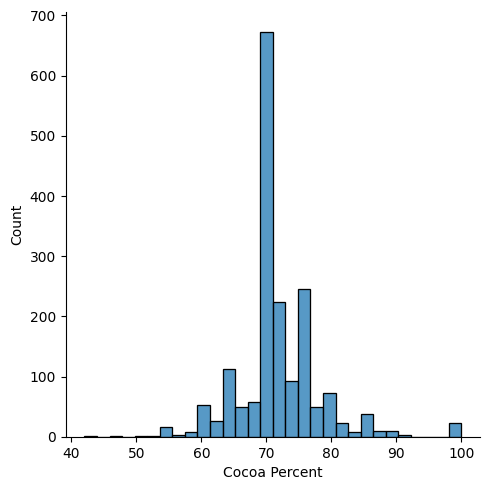

In [7]:
import seaborn as sns
sns.displot(df, x = 'Cocoa Percent', bins = 30)

In [8]:
df['Rating'] = df['Rating'] * (100 / df['Rating'].max())

df.head()

,Company,Specific Bean Origin,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,A. Morin,Agua Grande,2016,63.0,France,75.0,Blend,Sao Tome
1,A. Morin,Kpime,2015,70.0,France,55.0,Blend,Togo
2,A. Morin,Atsane,2015,70.0,France,60.0,Blend,Togo
3,A. Morin,Akata,2015,70.0,France,70.0,Blend,Togo
4,A. Morin,Quilla,2015,70.0,France,70.0,Blend,Peru


In [10]:
df['price(100g)'] = df['Cocoa Percent'] * 25 * df['Rating']
df.head()

,Company,Specific Bean Origin,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin,price(100g)
0,A. Morin,Agua Grande,2016,63.0,France,75.0,Blend,Sao Tome,118125.0
1,A. Morin,Kpime,2015,70.0,France,55.0,Blend,Togo,96250.0
2,A. Morin,Atsane,2015,70.0,France,60.0,Blend,Togo,105000.0
3,A. Morin,Akata,2015,70.0,France,70.0,Blend,Togo,122500.0
4,A. Morin,Quilla,2015,70.0,France,70.0,Blend,Peru,122500.0


In [11]:
dark_chocolates = df[df['Cocoa Percent'] > 70].reset_index(drop=True)

In [12]:
has_Trinitario = dark_chocolates['Bean Type'].str.contains('Trinitario')
has_Trinitario.head()

0     True
1     True
2     True
3     True
4    False
Name: Bean Type, dtype: boolean

In [13]:
dark_chocolates.loc[has_Trinitario, 'price(100g)'] *= 1.1

In [14]:
priceSum = dark_chocolates['price(100g)'].sum()

In [17]:
df.head()

,Company,Specific Bean Origin,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin,price(100g)
0,A. Morin,Agua Grande,2016,63.0,France,75.0,Blend,Sao Tome,118125.0
1,A. Morin,Kpime,2015,70.0,France,55.0,Blend,Togo,96250.0
2,A. Morin,Atsane,2015,70.0,France,60.0,Blend,Togo,105000.0
3,A. Morin,Akata,2015,70.0,France,70.0,Blend,Togo,122500.0
4,A. Morin,Quilla,2015,70.0,France,70.0,Blend,Peru,122500.0


In [18]:
df = df[df['Cocoa Percent'] <= 70].reset_index(drop=True)

In [19]:
companies = df.groupby(['Company','Review Date'])['Rating'].agg('mean').unstack()

In [20]:
companies.columns.name = None
companies.index.name = None

In [21]:
mean_ratings = companies.loc[:, companies.columns >= 2012].mean(axis=1)

In [22]:
best_ratings = mean_ratings.copy().reset_index().sort_values(by=[0, 'index'], ascending=[False, True]).set_index('index').head(10)

In [23]:
chocolates_to_sell = df[df['Company'].isin(best_ratings.index)].reset_index(drop=True)

In [24]:
priceSum = chocolates_to_sell['price(100g)'].sum()